Week2 Data Wrangler
This notebook covers:
1.Ingestion and profiling 
2.Reusable cleaning pipeline
3.Time series resampling and rolling average
4.Summary Table
5.Raw vs Cleaned Visualization

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import missingno as msno
from IPython.display import display, Markdown

pd.set_option('display.max_columns', None)

sensor_df = pd.read_csv('ops_sensor_log_dirty.csv')
print(sensor_df.shape)
sensor_df.head(30)

(5015, 6)


,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM
0,2026-07-01 18:28:00,Zone_South,Night,159.443407,83.599922,693.413088
1,2026-06-26 10:10:00,Zone_Central,NaN,271.325543,54.108382,933.590883
2,2026-06-29 22:10:00,Zone_Central,Morning,207.832279,72.549214,863.540549
3,2026-06-30 07:22:00,Zone_East,Night,203.110883,73.029484,1189.537650
4,2026-07-01 02:28:00,Zone_North,Morning,239.773496,73.752762,983.672559
5,2026-06-29 18:04:00,Zone_Central,Morning,170.679549,54.308328,1062.156470
6,2026-06-28 08:34:00,Zone_West,Afternoon,274.534204,60.531911,745.457729
7,2026-06-26 12:30:00,Zone_South,Morning,252.746989,64.763229,1052.418824
8,2026-07-01 04:38:00,Zone_West,Afternoon,129.690055,79.990855,1192.955542
9,2026-06-25 23:30:00,Zone_West,Afternoon,209.576861,81.822167,1193.161414


## 1. Ingestion & Profiling

In [3]:
sensor_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      5015 non-null   object 
 1   Zone           4984 non-null   object 
 2   Shift          4962 non-null   object 
 3   Pressure_PSI   4975 non-null   float64
 4   Temperature_C  4975 non-null   float64
 5   Flow_Rate_LPM  4966 non-null   float64
dtypes: float64(3), object(3)
memory usage: 235.2+ KB


In [4]:
sensor_df.describe()

,Pressure_PSI,Temperature_C,Flow_Rate_LPM
count,4975.000000,4975.000000,4966.000000
mean,255.254281,68.982323,999.275681
std,845.810206,78.829078,231.769525
min,-50.000000,-273.150000,600.007437
25%,160.753008,55.023155,797.417014
50%,200.294439,64.808608,996.286415
75%,240.099173,74.527006,1201.361276
max,15000.000000,1500.000000,1399.755865


In [5]:
print("Missing values per column:")
print(sensor_df.isnull().sum())
print()
print("Unique Zone values (raw):", sorted(sensor_df['Zone'].dropna().unique()))
print()
print("Unique Shift values (raw):", sorted(sensor_df['Shift'].dropna().unique()))
print()
print("Exact duplicate rows:", sensor_df.duplicated().sum())

Missing values per column:
timestamp         0
Zone             31
Shift            53
Pressure_PSI     40
Temperature_C    40
Flow_Rate_LPM    49
dtype: int64

Unique Zone values (raw): [' North Zone', ' South Zone', 'ZONE-NORTH', 'ZONE_SOUTH', 'Zone_Central', 'Zone_East', 'Zone_North', 'Zone_North ', 'Zone_South', 'Zone_South ', 'Zone_West', 'z_north', 'z_south', 'zone north', 'zone south']

Unique Shift values (raw): ['Afternoon', 'Morning', 'Night']

Exact duplicate rows: 15


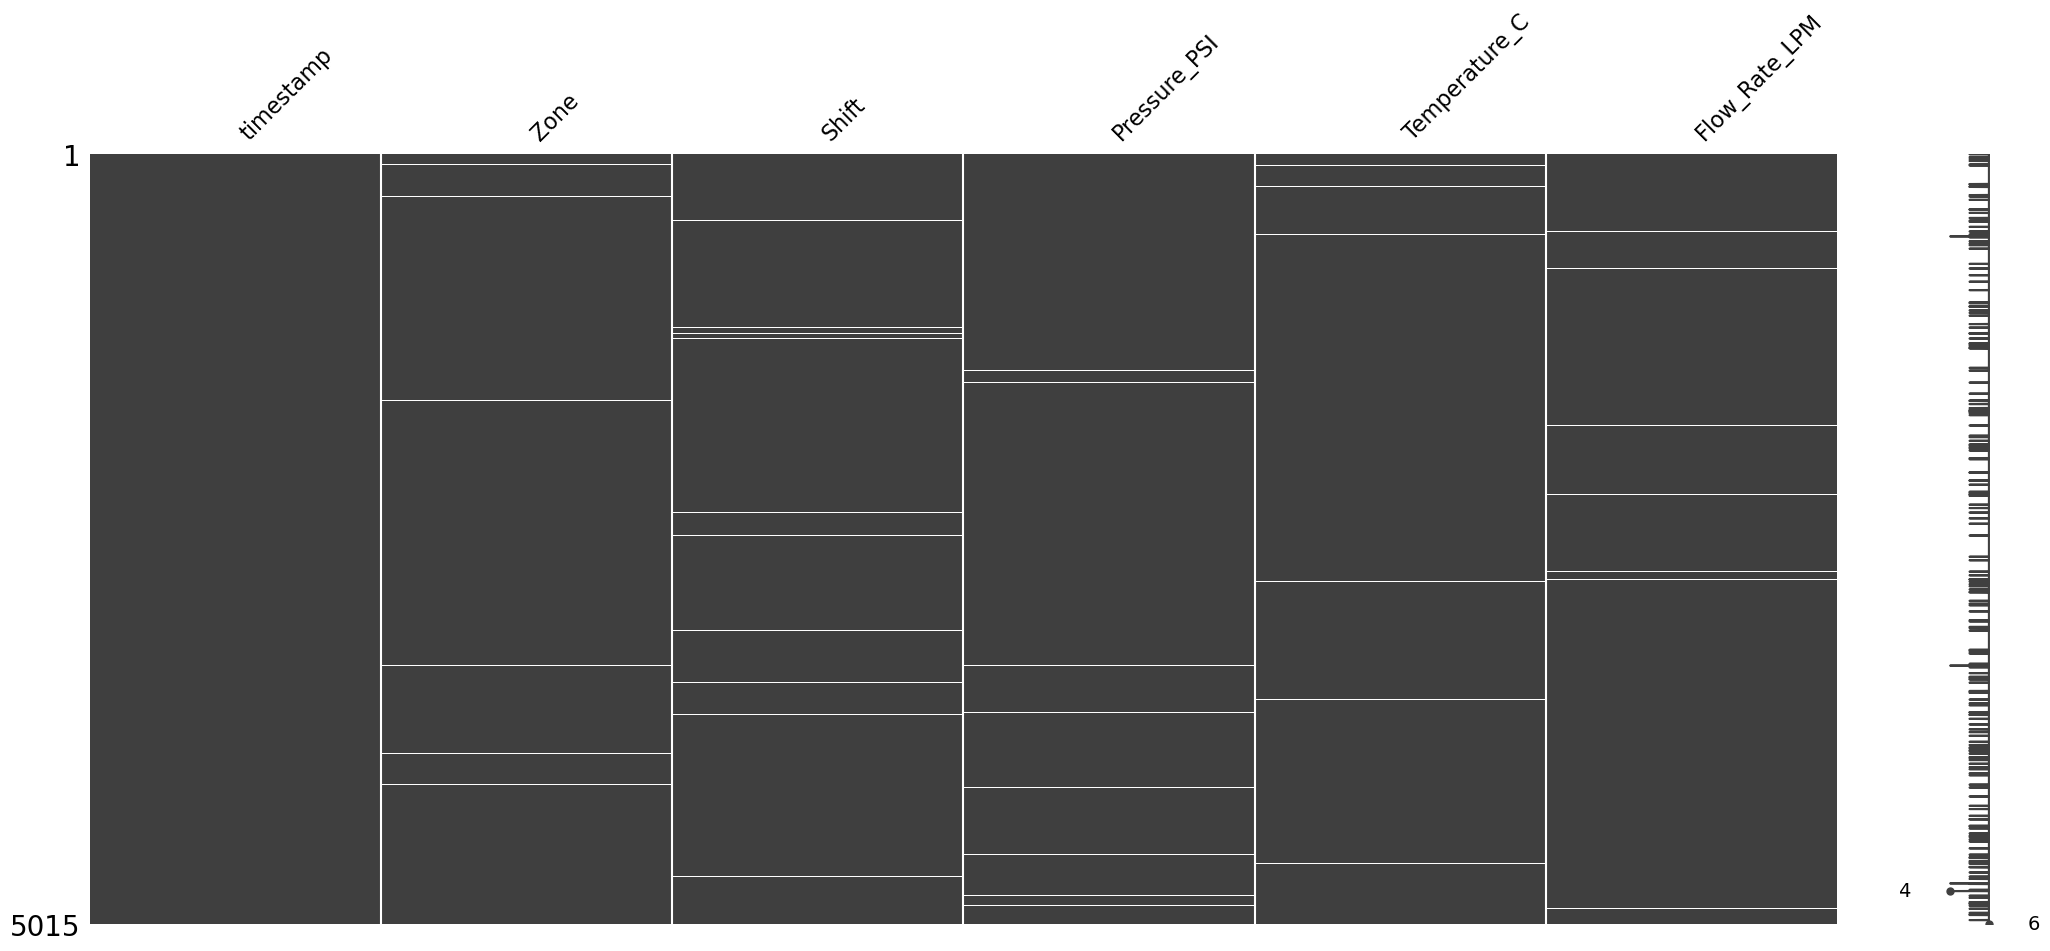

In [6]:

msno.matrix(sensor_df)
plt.show()


In [7]:
# Quantify the physically impossible sensor readings
n_neg_pressure = (sensor_df['Pressure_PSI'] < 0).sum()
n_extreme_pressure = (sensor_df['Pressure_PSI'] > 500).sum()
n_extreme_cold = (sensor_df['Temperature_C'] < -50).sum()
n_extreme_hot = (sensor_df['Temperature_C'] > 200).sum()

print(f"Pressure readings below 0 PSI (impossible): {n_neg_pressure}")
print(f"Pressure readings above 500 PSI (implausible for this system): {n_extreme_pressure}")
print(f"Temperature readings below -50C (impossible for this system): {n_extreme_cold}")
print(f"Temperature readings above 200C (implausible for this system): {n_extreme_hot}")
print()
print("Sample extreme values:")
print(sorted(sensor_df['Pressure_PSI'].dropna().unique())[:3], "...", sorted(sensor_df['Pressure_PSI'].dropna().unique())[-3:])
print(sorted(sensor_df['Temperature_C'].dropna().unique())[:3], "...", sorted(sensor_df['Temperature_C'].dropna().unique())[-3:])

Pressure readings below 0 PSI (impossible): 14
Pressure readings above 500 PSI (implausible for this system): 23
Temperature readings below -50C (impossible for this system): 10
Temperature readings above 200C (implausible for this system): 23

Sample extreme values:
[np.float64(-50.0), np.float64(0.0), np.float64(120.02963124727086)] ... [np.float64(279.9586035612948), np.float64(9999.0), np.float64(15000.0)]
[np.float64(-273.15), np.float64(0.0), np.float64(45.004745796434)] ... [np.float64(84.99570666820196), np.float64(800.0), np.float64(1500.0)]


### Data Health Report

**Dataset:** `ops_sensor_log_dirty.csv` — 5,015 rows x 6 columns

**Issue 1 — Missing values across every column.**
`Zone` (31 missing), `Shift` (53 missing), `Pressure_PSI` (40), `Temperature_C` (40), and
`Flow_Rate_LPM` (49) all contain nulls (~0.6-1% of rows each). Left unhandled, these break
groupby aggregations and any downstream math on the sensor columns.

**Issue 2 — Inconsistent categorical labels in `Zone`.**
What should be 5 zones (North, South, East, West, Central) instead appears as **16 distinct
string variants** — e.g. `Zone_South`, `ZONE_SOUTH`, `z_south`, `zone south`, `' South Zone'`,
`Zone_South ` (trailing space), `ZONE-NORTH`. Without standardization, groupby/aggregation
would treat each variant as a separate zone.

**Issue 3 — Physically impossible sensor readings (fault/error codes).**
- `Pressure_PSI` contains exact repeated values of **-50** (14 rows) and **15,000** (23 rows) —
  negative pressure is impossible, and 15,000 PSI is ~75x the normal operating range.
- `Temperature_C` contains exact repeated values of **-273.15** (10 rows, absolute zero) and
  **1,500** (23 rows) — both physically implausible for this equipment.

These are exact, repeated values rather than natural noise, strongly suggesting hard-coded
sensor fault/error codes rather than real readings.

**Issue 4 — Exact duplicate rows.**
15 fully duplicated records exist in the dataset (same timestamp, zone, shift, and all
sensor values), which would double-count those readings in any aggregation.

**Issue 5 — An isolated, out-of-range timestamp.**
5,014 of 5,015 records fall between late June and early July 2026, but one single record
is dated **2026-01-07** — six months earlier. This is very likely a manual data-entry error
and would create a massive artificial gap when resampling to an hourly time series.


## 2. Cleaning Pipeline

In [8]:


RAW_PATH = "ops_sensor_log_dirty.csv"

def clean_ops_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Reusable cleaning pipeline for the ops sensor log.

    Steps:
    1. Parse timestamp -> datetime
    2. Standardize categorical columns (Zone naming chaos -> canonical form)
    3. Drop rows with missing Zone/Shift (can't be safely imputed - they are
       grouping keys, and guessing a zone/shift would corrupt aggregation)
    4. Filter out physically impossible sensor readings (sentinel error codes)
    5. Time-interpolate missing numeric sensor values (readings drift smoothly
       over time, so interpolation preserves the trend better than mean-fill
       or dropping, which would create time gaps)
    6. Drop exact duplicate rows
    """
    df = df.copy()

    # 1. Timestamps
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df = df.dropna(subset=['timestamp'])

    # Drop isolated timestamp outliers (e.g. a single Jan record sitting
    # 6 months away from the main Jun-Jul cluster). Using the mode month
    # as the anchor keeps this robust rather than hardcoding a date.
    dominant_month = df['timestamp'].dt.to_period('M').mode()[0]
    month_span = pd.PeriodIndex([dominant_month - 1, dominant_month, dominant_month + 1])
    before_ts = len(df)
    df = df[df['timestamp'].dt.to_period('M').isin(month_span)]
    dropped_stray_dates = before_ts - len(df)

    # 2. Standardize categorical: Zone
    def normalize_zone(z):
        if pd.isna(z):
            return np.nan
        z = str(z).strip().lower()
        z = z.replace('zone-', 'zone_').replace(' zone', '').replace('zone ', '')
        z = z.replace('-', '_').replace(' ', '_')
        z = z.replace('__', '_')
        # z might now be like 'zone_south', 'z_south', 'south_zone', 'south'
        for direction in ['north', 'south', 'east', 'west', 'central']:
            if direction in z:
                return f"Zone_{direction.capitalize()}"
        return z

    df['Zone'] = df['Zone'].apply(normalize_zone)
    df['Shift'] = df['Shift'].astype(str).str.strip().str.capitalize().replace('Nan', np.nan)

    # 3. Drop rows with missing grouping keys
    before = len(df)
    df = df.dropna(subset=['Zone', 'Shift'])
    dropped_keys = before - len(df)

    # 4. Filter impossible physical readings (sentinel/error codes)
    #    Pressure: valid range 0-500 PSI (legit data clusters 100-300)
    #    Temperature: valid range -20-150 C (legit data clusters 40-90)
    #    Flow: valid range 0-2000 LPM (legit data clusters 600-1400, generous bound)
    before = len(df)
    pressure_mask = df['Pressure_PSI'].between(0, 500) | df['Pressure_PSI'].isna()
    temp_mask = df['Temperature_C'].between(-20, 150) | df['Temperature_C'].isna()
    flow_mask = df['Flow_Rate_LPM'].between(0, 2000) | df['Flow_Rate_LPM'].isna()
    df = df[pressure_mask & temp_mask & flow_mask]
    dropped_outliers = before - len(df)

    # 5. Sort + time-interpolate remaining missing numeric values
    df = df.sort_values('timestamp')
    for col in ['Pressure_PSI', 'Temperature_C', 'Flow_Rate_LPM']:
        df[col] = df[col].interpolate(method='linear', limit_direction='both')

    # 6. Drop exact duplicates
    before = len(df)
    df = df.drop_duplicates()
    dropped_dupes = before - len(df)

    df = df.reset_index(drop=True)
    return df, {"dropped_stray_dates": dropped_stray_dates,
                "dropped_missing_keys": dropped_keys,
                "dropped_outliers": dropped_outliers,
                "dropped_duplicates": dropped_dupes}

**Design choices, justified:**

- **Missing `Zone` / `Shift` → dropped.** These are grouping keys used throughout the
  analysis (Part 4). There's no reliable way to infer which zone or shift a reading belongs
  to, and guessing would silently corrupt every aggregation downstream. Only ~1.6% of rows
  are affected, so dropping is low-cost.
- **Missing `Pressure_PSI` / `Temperature_C` / `Flow_Rate_LPM` → linear time-interpolation.**
  Sensor readings drift smoothly over short time windows, so interpolating between the
  readings immediately before/after a gap is more faithful than a global mean-fill (which
  would flatten real trends) or dropping (which would create holes in the hourly time series
  needed for Part 3).
- **Impossible readings → filtered by physical bounds**, not just the exact sentinel values,
  so any other implausible reading (not just -50/15000/-273.15/1500) is also caught.
- **Isolated timestamp outlier → dropped** using the dominant month as an anchor, so the
  logic isn't hardcoded to one specific date and would generalize to future data pulls.
- **Duplicates → dropped last**, after cleaning, so any duplicate created incidentally by
  interpolation/rounding is also caught.

In [11]:
cleaned, stats = clean_ops_data(sensor_df)

print("Raw shape:    ", sensor_df.shape)
print("Cleaned shape:", cleaned.shape)
print()
print("Rows removed at each stage:", stats)
print()
print("Cleaned Zone values:", sorted(cleaned['Zone'].unique()))
print("Cleaned Shift values:", sorted(cleaned['Shift'].unique()))
print()
cleaned.describe()

Raw shape:     (5015, 6)
Cleaned shape: (4849, 6)

Rows removed at each stage: {'dropped_stray_dates': 1, 'dropped_missing_keys': 83, 'dropped_outliers': 69, 'dropped_duplicates': 13}

Cleaned Zone values: ['Zone_Central', 'Zone_East', 'Zone_North', 'Zone_South', 'Zone_West']
Cleaned Shift values: ['Afternoon', 'Morning', 'Night']



,timestamp,Pressure_PSI,Temperature_C,Flow_Rate_LPM
count,4849,4849.000000,4849.000000,4849.000000
mean,2026-06-28 11:03:37.999587584,199.580455,64.704106,1000.025400
min,2026-06-25 00:00:00,0.000000,0.000000,600.007437
25%,2026-06-26 17:24:00,160.956921,55.080227,798.594026
50%,2026-06-28 11:04:00,200.150191,64.791074,998.517726
75%,2026-06-30 04:36:00,239.638462,74.365984,1200.953432
max,2026-07-01 22:38:00,279.958604,84.995707,1399.755865
std,NaN,47.164028,11.974765,231.201833


## 3. Time-Series Analysis

Resampling to hourly frequency and computing a 24-hour rolling average on `Pressure_PSI`
(the primary metric — change `PRIMARY_METRIC` below to analyze a different column).

In [12]:
PRIMARY_METRIC = "Pressure_PSI"

ts = cleaned.set_index('timestamp').sort_index()
hourly = ts[PRIMARY_METRIC].resample('h').mean()
rolling_24h = hourly.rolling(window=24, min_periods=1).mean()

hourly_df = pd.DataFrame({
    f'{PRIMARY_METRIC}_hourly_mean': hourly,
    f'{PRIMARY_METRIC}_24h_rolling_avg': rolling_24h
})
hourly_df.head(10)

,Pressure_PSI_hourly_mean,Pressure_PSI_24h_rolling_avg
timestamp,,
2026-06-25 00:00:00,203.351000,203.351000
2026-06-25 01:00:00,196.280484,199.815742
2026-06-25 02:00:00,188.648468,196.093317
2026-06-25 03:00:00,198.603934,196.720972
2026-06-25 04:00:00,190.216348,195.420047
2026-06-25 05:00:00,220.896316,199.666092
2026-06-25 06:00:00,197.561064,199.365373
2026-06-25 07:00:00,218.125409,201.710378
2026-06-25 08:00:00,202.602072,201.809455


## 4. Aggregation — Mean / Max / Min by Shift and Zone

In [13]:
summary_table = (
    cleaned.groupby(['Shift', 'Zone'])[PRIMARY_METRIC]
    .agg(['mean', 'max', 'min'])
    .round(2)
    .rename(columns={'mean': 'Mean', 'max': 'Max', 'min': 'Min'})
)
summary_table

Mean     Max     Min
Shift     Zone                                
Afternoon Zone_Central  199.08  279.94    0.00
          Zone_East     204.05  278.85  120.86
          Zone_North    202.79  279.85    0.00
          Zone_South    202.19  279.72    0.00
          Zone_West     196.87  279.61    0.00
Morning   Zone_Central  198.68  279.89    0.00
          Zone_East     197.66  279.95    0.00
          Zone_North    202.72  279.52    0.00
          Zone_South    195.51  279.43  121.28
          Zone_West     195.23  279.90  120.57
Night     Zone_Central  198.79  279.92  120.18
          Zone_East     201.59  279.89  120.45
          Zone_North    200.31  279.96    0.00
          Zone_South    199.23  278.70    0.00
          Zone_West     198.47  279.61    0.00

## 5. Visualization — Raw vs Cleaned Trend

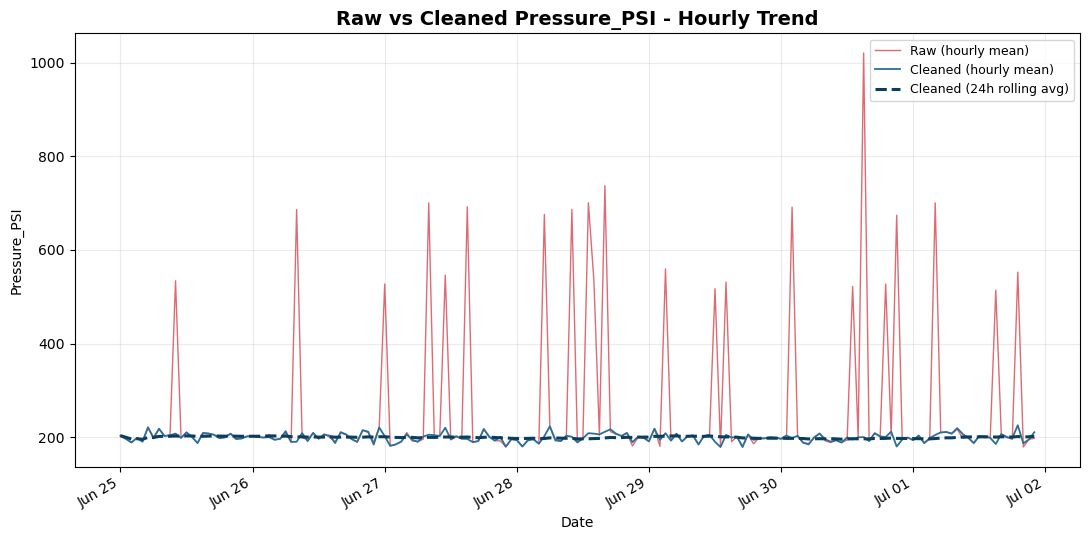

In [15]:
raw_for_plot = sensor_df.copy()
raw_for_plot['timestamp'] = pd.to_datetime(raw_for_plot['timestamp'], errors='coerce')
raw_ts = raw_for_plot.dropna(subset=['timestamp']).set_index('timestamp').sort_index()
# Exclude the single isolated Jan record here purely for chart readability
# (it is already excluded from `cleaned` by clean_ops_data as a data-quality fix)
raw_ts = raw_ts[raw_ts.index >= '2026-06-01']
raw_hourly = raw_ts[PRIMARY_METRIC].resample('h').mean()

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(raw_hourly.index, raw_hourly.values, color='#d64550', linewidth=1, alpha=0.8, label='Raw (hourly mean)')
ax.plot(hourly.index, hourly.values, color='#2a6f97', linewidth=1.3, label='Cleaned (hourly mean)')
ax.plot(rolling_24h.index, rolling_24h.values, color='#0b3d5c', linewidth=2.2, linestyle='--', label='Cleaned (24h rolling avg)')

ax.set_title(f"Raw vs Cleaned {PRIMARY_METRIC} - Hourly Trend", fontsize=14, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel(PRIMARY_METRIC)
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.autofmt_xdate()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('raw_vs_cleaned_plot.png', dpi=150)
plt.show()